# Imports

In [573]:
import sklearn
from sklearn.model_selection import train_test_split

In [574]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datasets


## Real world dataset


Load the real world dataset and display the structure

In [575]:


''' dataset = sklearn.datasets.fetch_california_housing( return_X_y=False, as_frame=False) '''

' dataset = sklearn.datasets.fetch_california_housing( return_X_y=False, as_frame=False) '

In [576]:
''' print(dataset.data[0]) '''

' print(dataset.data[0]) '

In [577]:
''' print(dataset.target) '''

' print(dataset.target) '

## Synthetic dataset


In [578]:
def generate_synthetic_data(n_samples=200, n_features=20, noise=5.0, seed=42):
    np.random.seed(seed)

    # Create correlated features
    X = np.random.randn(n_samples, n_features)

    # Introduce correlation (important for ridge usefulness)
    X[:, 1] = X[:, 0] + 0.01 * np.random.randn(n_samples)
    X[:, 2] = X[:, 0] - 0.01 * np.random.randn(n_samples)

    # True weights (sparse-ish)
    true_w = np.zeros(n_features)
    true_w[:5] = [5, -3, 2, 0, 1]

    # Generate targets
    y = X @ true_w + noise * np.random.randn(n_samples)

    return X, y, true_w

# Data augmentation

Create a random permuntation so I can make sure that the model works and not only with single permuntation

In [579]:
def loadRealData():
  dataset = sklearn.datasets.load_diabetes( return_X_y=False, as_frame=False)
  X = dataset.data
  Y = dataset.target
  return X, Y

In [580]:
#set seed for this to be reproducible
def assingPermuntation(X, Y, seed = 42):
  np.random.seed(seed)

  n = X.shape[0]
  perm = np.random.permutation(n)

  X = X[perm]
  Y = Y[perm]
  return X, Y

Create the training, test, val  split

In [581]:
''' def trainSplit(X, Y):
   X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
   return X_train, X_test, y_train, y_test '''

def train_val_test_split(X, y, seed=42):
  X_train_full, X_test, y_train_full, y_test = train_test_split(
      X, y, test_size=0.2, random_state=seed
  )
  X_train, X_val, y_train, y_val = train_test_split(
      X_train_full, y_train_full, test_size=0.25, random_state=seed
  )
  return X_train, X_val, X_test, y_train, y_val, y_test


The trouble I ran into was the dataset not being expressive enough, so I'm creating polynomial features

In [582]:
# Adding more features, x^^2
def polySquared(X_tr, X_te):
  X_train = np.c_[X_tr, X_tr**2]
  X_test = np.c_[X_te, X_te**2]
  return X_train, X_test



Add a bias to the datapoints, enables the model to learn the intercept

In [583]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]



# helper functions

Determine simple functions

In [584]:
#Error

def calculcateError( label, predi):
  # square error
  predictionError = ( predi - label ) ** 2
  ''' print( predictionError)  '''
  return predictionError


''' def sumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = calculcateError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError '''


# Non squared error
''' def simpleError( label, predi):
  predictionError =  predi - label
  print( predictionError)
  return predictionError
 '''



# Non squared error
''' def simpleSumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = simpleError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError '''

#Mean squared error
def mse(y_pred, y):
    return np.mean((y_pred - y) ** 2)


# crude and easy implementation of a prediction
def predict(X, w):
    return X @ w


In [585]:

def getFeatureBlame( X, y, y_pred):

    # figure out how each feature contributed to those errors
    return (X.T @ (y_pred - y))

Ridge specific helpers

In [586]:
# ridge addon for weights
''' def getRidgePenalty(alpha, w):
    total = 0
    for i in range(len(w)):
      total += (w[i] ** 2)


    return alpha * total '''


def getRidgeGradient(alpha, w):

  reg = 2 * alpha * w
  reg[0] = 0
  return reg

# Ridge model

In [587]:
# L2, ridge
def ridge(X, y, alpha = 1, lR = 0.001, epochs = 10000):


  prev_loss = float("inf")


  m, n = X.shape

  # Create weights
  w = np.zeros(n)

  for i in range(epochs):
    y_pred = predict(X, w)


    ''' loss  = sumError(y_pred, y) '''
    loss = mse(y_pred, y) + alpha * np.sum(w[1:]**2)
    # Drop learning rate if we see no  development
    if loss >= prev_loss:
      lR *= 0.8
    prev_loss = loss

    gradient = (2 / m) *  getFeatureBlame(X, y ,y_pred) + getRidgeGradient(alpha, w)
    '''   print(gradient) '''
    # update weights
    w = w - lR * gradient


    ''' print(w ) '''
  return w

## Lets find good weights


Fiddleling around with alpha and learning rate to find a good candidate or in a way "fitting" the model. Takes aprox 2min

In [588]:
def fitRidge(X_train, X_val, y_train, y_val, epochs= 1000, alphas = [ 1e-4, 1e-3, 1e-2, 1e-1, 1, 10], lrs = [  1e-4 , 1e-3, 1e-2]):
  best_mse = float("inf")
  best_alpha = None
  best_lr = None
  best_w = None

  for alpha in alphas:
    '''  for alpha in np.logspace(-4, 3, 20): '''
    for lr in lrs:

      w = ridge(  X_train, y_train, alpha=alpha, lR=lr, epochs = epochs)
      pred = predict(X_val, w)
      current_mse = mse(pred, y_val)
      print("alpha: ", alpha,"lr: ", lr,"mse: ", current_mse)

      # Look if the score is worse or same
      if current_mse < best_mse:
        # Update best variables
        best_mse = current_mse
        best_alpha = alpha
        best_lr = lr
        best_w = w

    print("alpha:", alpha, "||w||:", np.linalg.norm(w))
  print("\nBEST RESULT:")
  print("alpha:", best_alpha, "lr:", best_lr, "mse:", best_mse)

  return best_w

# Data preprosessing

## Real world dataset

In [589]:
X_real, Y_real = loadRealData()
X_real, Y_real = assingPermuntation(X_real, Y_real, seed = 42)


''' X_real_train, X_real_test, y_real_train, y_real_test  = trainSplit(X_real, Y_real) '''
X_real_train,X_real_val, X_real_test, y_real_train, y_real_val, y_real_test  = train_val_test_split(X_real, Y_real)

X_real_train = add_bias(X_real_train)
X_real_val = add_bias(X_real_val)
X_real_test = add_bias(X_real_test)



## Synthetic dataset

In [590]:
X_synt, Y_synt, synth_true_w = generate_synthetic_data(n_samples=120, n_features=80, noise=3.0, seed=42)
X_synt, Y_synt = assingPermuntation(X_synt, Y_synt, seed = 42)
''' X_synt_train, X_synt_test, y_synt_train, y_synt_test  = trainSplit(X_synt, Y_synt)
 '''
X_synt_train,X_synt_val, X_synt_test, y_synt_train,y_synt_val, y_synt_test  = train_val_test_split(X_synt, Y_synt)

# Add bias so we're not completely lost
X_synt_train = add_bias(X_synt_train)
X_synt_val = add_bias(X_synt_val)
X_synt_test = add_bias(X_synt_test)


## Training

## Real world dataset

In [591]:

# Retrieve ridge weights from a crude implementation
best_real_w = fitRidge(X_real_train, X_real_val, y_real_train, y_real_val, epochs = 20000, alphas = [ 1e-4, 1e-3, 1e-2, 1e-1, 1, 10], lrs = [  1e-4 , 1e-3, 1e-2])
testPredictions = predict(X_real_test, best_real_w)


print("\nTesting against test set")


mse_test = mse(y_real_test, testPredictions)
rmse_test = np.sqrt(mse_test)
print("test set MSE: ",mse_test,"RMSE: ", rmse_test)

alpha:  0.0001 lr:  0.0001 mse:  6652.62003367233
alpha:  0.0001 lr:  0.001 mse:  5501.364483186423
alpha:  0.0001 lr:  0.01 mse:  3628.8639807639847
alpha: 0.0001 ||w||: 651.2929793963604
alpha:  0.001 lr:  0.0001 mse:  6652.921033473625
alpha:  0.001 lr:  0.001 mse:  5519.657003434425
alpha:  0.001 lr:  0.01 mse:  3745.4225747325063
alpha: 0.001 ||w||: 585.7055674285746
alpha:  0.01 lr:  0.0001 mse:  6655.892942116443
alpha:  0.01 lr:  0.001 mse:  5686.556744092434
alpha:  0.01 lr:  0.01 mse:  4834.8446456595475
alpha: 0.01 ||w||: 305.88328089470616
alpha:  0.1 lr:  0.0001 mse:  6682.140646606347
alpha:  0.1 lr:  0.001 mse:  6412.621274629227
alpha:  0.1 lr:  0.01 mse:  6407.473308766703
alpha: 0.1 ||w||: 160.29307977371676
alpha:  1 lr:  0.0001 mse:  6781.356861924409
alpha:  1 lr:  0.001 mse:  6759.7814961524555
alpha:  1 lr:  0.01 mse:  6759.781408663024
alpha: 1 ||w||: 154.63227125198654
alpha:  10 lr:  0.0001 mse:  6820.373398927471
alpha:  10 lr:  0.001 mse:  6799.321065206902


In [592]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_real_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_real_test[i]))

Error for 0: 165.4889615164936, Prediction: 153.8642513002698, label : 141.0
Error for 1: 4592.016051822266, Prediction: 176.76441582292483, label : 109.0
Error for 2: 1878.9513543147098, Prediction: 237.6531275140327, label : 281.0
Error for 3: 268.3013872060662, Prediction: 246.62009196588497, label : 263.0
Error for 4: 7200.382162497343, Prediction: 145.8550656266162, label : 61.0
Error for 5: 971.4462469281318, Prediction: 168.83196754801273, label : 200.0
Error for 6: 12220.128480066063, Prediction: 181.45531003224957, label : 292.0
Error for 7: 6544.569306013302, Prediction: 153.89851238442708, label : 73.0
Error for 8: 18.099300318298283, Prediction: 87.2543272462633, label : 83.0
Error for 9: 2332.5881701940966, Prediction: 164.2968753667781, label : 116.0


In [593]:
print(best_real_w)

[ 154.32335318   55.52832912  -65.15746715  362.99862056  249.03616682
   13.02349013  -46.54622222 -189.94696381  133.1498981   355.91151738
  128.19138494]


 ### Visualization

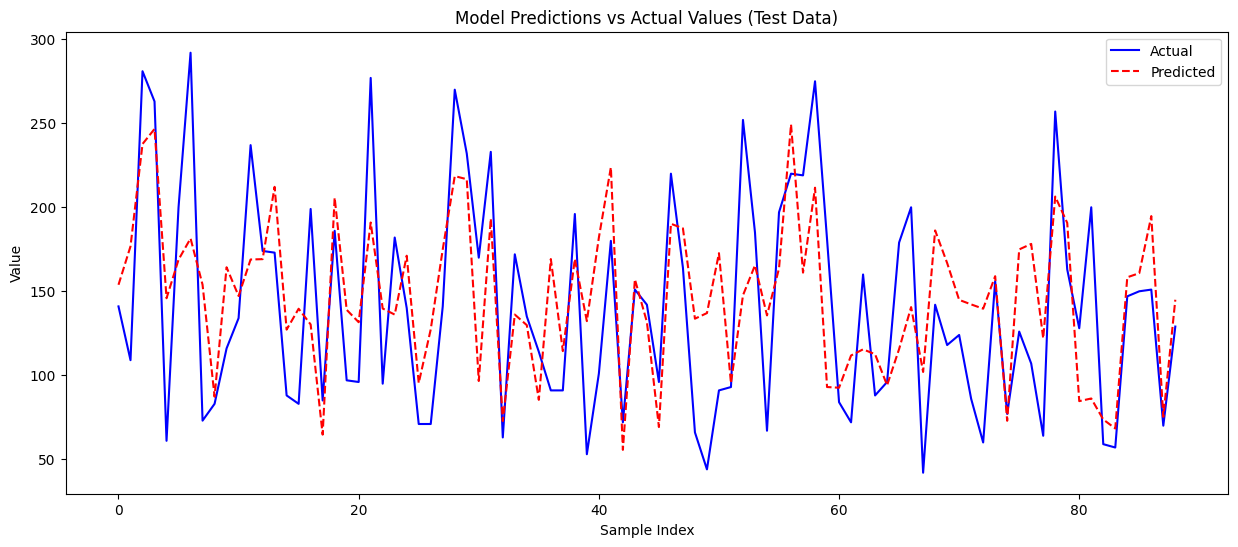

In [594]:
num_samples_to_plot = len(X_real_test)
indices = np.arange(num_samples_to_plot)

plt.figure(figsize=(15, 6))
plt.plot(indices, y_real_test[:num_samples_to_plot], 'b-', label='Actual')
plt.plot(indices, testPredictions[:num_samples_to_plot], 'r--', label='Predicted')
plt.title('Model Predictions vs Actual Values (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()

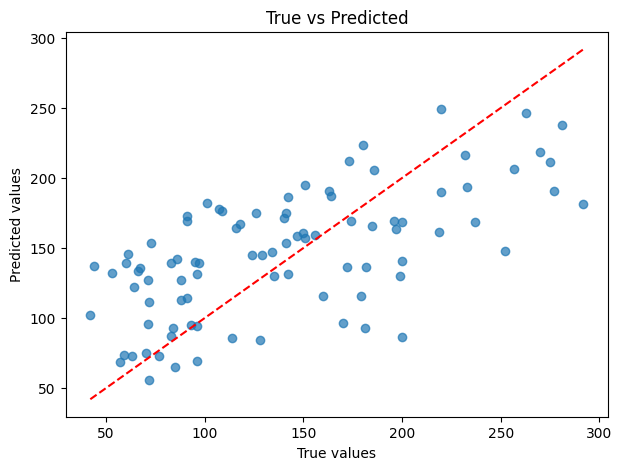

In [595]:
plt.figure(figsize=(7, 5))
plt.scatter(y_real_test, testPredictions, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

min_val = min(y_real_test.min(), testPredictions.min())
max_val = max(y_real_test.max(), testPredictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()

## Synthetic dataset


In [596]:

# Retrieve ridge weights from a crude implementation
best_synt_w = fitRidge(X_synt_train, X_synt_val, y_synt_train, y_synt_val, epochs = 20000, alphas = [ 1e-4, 1e-3, 1e-2, 1e-1, 1, 10], lrs = [  1e-4 , 1e-3, 1e-2])

# Last test predictions
testPredictions = predict(X_synt_test, best_synt_w)

print("\nTesting against test set")
''' print("SumError: " ,sumError(testPredictions, y_synt_test))
 '''


mse_test = mse(y_synt_test, testPredictions)
rmse_test = np.sqrt(mse_test)


print("test set MSE: ",mse_test,"RMSE: ", rmse_test)

alpha:  0.0001 lr:  0.0001 mse:  10.418248110765417
alpha:  0.0001 lr:  0.001 mse:  31.200570162762716
alpha:  0.0001 lr:  0.01 mse:  58.684743342640296
alpha: 0.0001 ||w||: 8.149576358715713
alpha:  0.001 lr:  0.0001 mse:  10.411572218861854
alpha:  0.001 lr:  0.001 mse:  30.676987022083598
alpha:  0.001 lr:  0.01 mse:  55.069926193852325
alpha: 0.001 ||w||: 7.858237335576367
alpha:  0.01 lr:  0.0001 mse:  10.3465541144921
alpha:  0.01 lr:  0.001 mse:  26.272200813986235
alpha:  0.01 lr:  0.01 mse:  35.60281417042962
alpha: 0.01 ||w||: 6.199895851712514
alpha:  0.1 lr:  0.0001 mse:  9.846169259042245
alpha:  0.1 lr:  0.001 mse:  12.832619475312427
alpha:  0.1 lr:  0.01 mse:  12.889435861219573
alpha: 0.1 ||w||: 3.443443066238703
alpha:  1 lr:  0.0001 mse:  9.869138441463127
alpha:  1 lr:  0.001 mse:  9.860572600801534
alpha:  1 lr:  0.01 mse:  9.86057238416801
alpha: 1 ||w||: 1.9163568393725507
alpha:  10 lr:  0.0001 mse:  16.691367917586774
alpha:  10 lr:  0.001 mse:  16.687682812055

In [597]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_synt_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_synt_test[i]))

Error for 0: 5.350204817280553, Prediction: -0.14876969511933388, label : -2.4618206710557815
Error for 1: 8.158068918792557, Prediction: -0.44872424752870915, label : -3.3049575921265477
Error for 2: 1.4901382516388755, Prediction: 1.6338515416625812, label : 0.41313935132495894
Error for 3: 0.0673479955006803, Prediction: -2.040585747766383, label : -2.300100671230681
Error for 4: 0.3561007246521996, Prediction: 1.7186866756290056, label : 2.315428432716776
Error for 5: 2.6011146366237847, Prediction: -2.1679074375135317, label : -0.555110290745289
Error for 6: 4.686979323350981, Prediction: 2.646542474153311, label : 0.4815992131529261
Error for 7: 7.28142100236258, Prediction: 1.9707560221450067, label : 4.669166851200245
Error for 8: 19.050642566557876, Prediction: 5.969419122585686, label : 10.334123301170745
Error for 9: 1.950185741647979, Prediction: 7.552541589127722, label : 6.156051080156043


### Visualization


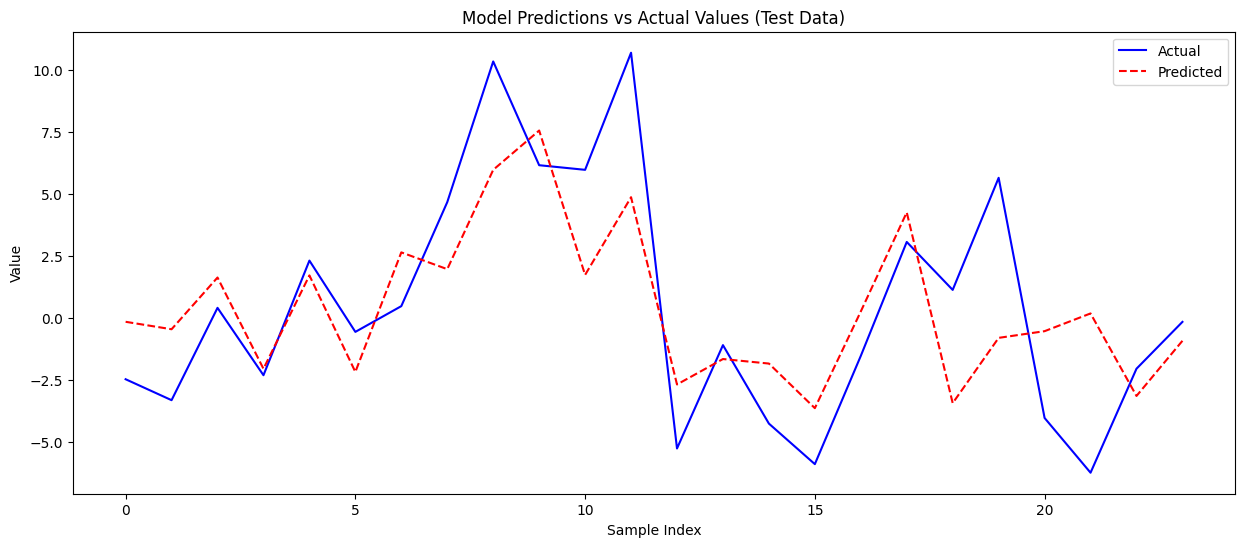

In [598]:
num_samples_to_plot = len(X_synt_test)
indices = np.arange(num_samples_to_plot)

plt.figure(figsize=(15, 6))
plt.plot(indices, y_synt_test[:num_samples_to_plot], 'b-', label='Actual')
plt.plot(indices, testPredictions[:num_samples_to_plot], 'r--', label='Predicted')
plt.title('Model Predictions vs Actual Values (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()

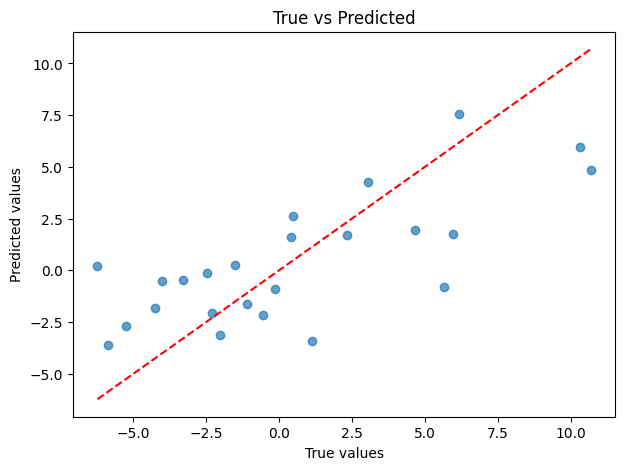

In [599]:
plt.figure(figsize=(7, 5))
plt.scatter(y_synt_test, testPredictions, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

min_val = min(y_synt_test.min(), testPredictions.min())
max_val = max(y_synt_test.max(), testPredictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()

# Testing generilization


In [600]:
def fit_fixed_alpha(X_train, X_val, y_train, y_val, alpha, epochs=5000, lrs=[1e-4, 1e-3, 1e-2]):
    best_val_mse = float("inf")
    best_lr = None
    best_w = None

    for lr in lrs:
        w = ridge(X_train, y_train, alpha=alpha, lR=lr, epochs=epochs)
        pred_val = predict(X_val, w)
        val_mse = mse(pred_val, y_val)

        if np.isnan(val_mse) or np.isinf(val_mse):
            continue

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_lr = lr
            best_w = w

    if best_w is None:
        return None

    train_pred = predict(X_train, best_w)
    val_pred = predict(X_val, best_w)

    return {
        "alpha": alpha,
        "lr": best_lr,
        "w": best_w,
        "train_mse": mse(train_pred, y_train),
        "val_mse": mse(val_pred, y_val)
    }


In [601]:
def estimate_stability(X_train, y_train, X_val, y_val, X_test, y_test,
                       alpha, epochs=3000, lrs=[1e-4, 1e-3, 1e-2], max_removed_points=None):
    """
    Stability metric:
    average absolute change in predictions on the fixed test set
    after removing one training point and retraining.
    """

    base_result = fit_fixed_alpha(X_train, X_val, y_train, y_val, alpha, epochs=epochs, lrs=lrs)

    if base_result is None:
        return None

    base_w = base_result["w"]
    base_lr = base_result["lr"]
    base_test_pred = predict(X_test, base_w)
    base_test_mse = mse(base_test_pred, y_test)

    n_train = X_train.shape[0]
    indices = np.arange(n_train)

    # Optional: use only part of the training set for faster experiments
    if max_removed_points is not None:
        indices = indices[:max_removed_points]

    prediction_changes = []
    loss_changes = []

    for i in indices:
        X_train_minus_i = np.delete(X_train, i, axis=0)
        y_train_minus_i = np.delete(y_train, i, axis=0)

        # Keep alpha fixed and use the same learning rate chosen on validation set
        w_minus_i = ridge(X_train_minus_i, y_train_minus_i, alpha=alpha, lR=base_lr, epochs=epochs)
        pred_minus_i = predict(X_test, w_minus_i)

        pred_change = np.mean(np.abs(base_test_pred - pred_minus_i))
        loss_change = abs(mse(pred_minus_i, y_test) - base_test_mse)

        prediction_changes.append(pred_change)
        loss_changes.append(loss_change)

    return {
        "alpha": alpha,
        "lr": base_lr,
        "train_mse": base_result["train_mse"],
        "val_mse": base_result["val_mse"],
        "test_mse": base_test_mse,
        "stability_pred": np.mean(prediction_changes),
        "stability_loss": np.mean(loss_changes)
    }

In [602]:
def run_stability_experiment(X_train, y_train, X_val, y_val, X_test, y_test,
                             alphas=[0, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
                             epochs=3000,
                             lrs=[1e-4, 1e-3, 1e-2],
                             max_removed_points=None):
    results = []

    for alpha in alphas:
        result = estimate_stability(
            X_train, y_train, X_val, y_val, X_test, y_test,
            alpha=alpha,
            epochs=epochs,
            lrs=lrs,
            max_removed_points=max_removed_points
        )

        if result is not None:
            results.append(result)
            print(
                "alpha:", result["alpha"],
                "| lr:", result["lr"],
                "| train_mse:", result["train_mse"],
                "| test_mse:", result["test_mse"],
                "| stability_pred:", result["stability_pred"],
                "| stability_loss:", result["stability_loss"]
            )

    return pd.DataFrame(results)

## Visualization helper

In [604]:
def plot_stability_results(df, title_prefix="Dataset"):
    alpha_labels = [str(a) for a in df["alpha"]]
    x = np.arange(len(df))

    # Train vs test error
    plt.figure(figsize=(10, 5))
    plt.plot(x, df["train_mse"], marker='o', label="Train MSE")
    plt.plot(x, df["test_mse"], marker='s', label="Test MSE")
    plt.xticks(x, alpha_labels)
    plt.xlabel("alpha")
    plt.ylabel("MSE")
    plt.title(f"{title_prefix}: Train/Test error vs regularization")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Stability based on prediction change
    plt.figure(figsize=(10, 5))
    plt.plot(x, df["stability_pred"], marker='o')
    plt.xticks(x, alpha_labels)
    plt.xlabel("alpha")
    plt.ylabel("Average prediction change")
    plt.title(f"{title_prefix}: Stability vs regularization")
    plt.grid(True)
    plt.show()

    # Stability based on loss change
    plt.figure(figsize=(10, 5))
    plt.plot(x, df["stability_loss"], marker='o')
    plt.xticks(x, alpha_labels)
    plt.xlabel("alpha")
    plt.ylabel("Average change in test MSE")
    plt.title(f"{title_prefix}: Stability (loss-based) vs regularization")
    plt.grid(True)
    plt.show()

## Real world dataset

alpha: 0 | lr: 0.01 | train_mse: 4514.612293992038 | test_mse: 3228.631901356739 | stability_pred: 0.23320131434341498 | stability_loss: 5.320008586368249
alpha: 0.0001 | lr: 0.01 | train_mse: 4518.149974763833 | test_mse: 3231.0176161695535 | stability_pred: 0.23323196349663577 | stability_loss: 5.32444405470028
alpha: 0.001 | lr: 0.01 | train_mse: 4549.624041490722 | test_mse: 3252.295905556054 | stability_pred: 0.23352521738218462 | stability_loss: 5.363241855395461
alpha: 0.01 | lr: 0.01 | train_mse: 4828.758987975102 | test_mse: 3444.7049579462996 | stability_pred: 0.23742914178213442 | stability_loss: 5.689238245230638
alpha: 0.1 | lr: 0.01 | train_mse: 5781.237550858597 | test_mse: 4136.026642252092 | stability_pred: 0.2572731676021832 | stability_loss: 6.980669745777004
alpha: 1 | lr: 0.01 | train_mse: 6113.48029005261 | test_mse: 4386.499477372208 | stability_pred: 0.26444932357940926 | stability_loss: 7.5452035593106075
alpha: 10 | lr: 0.01 | train_mse: 6150.6842125548 | test

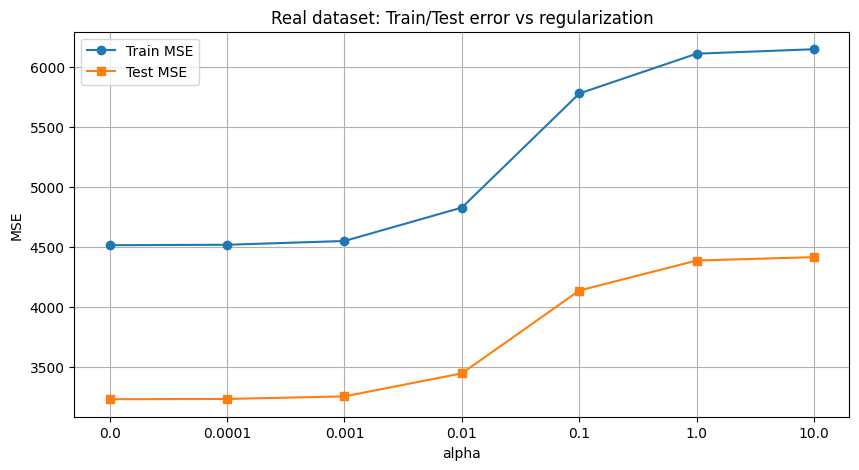

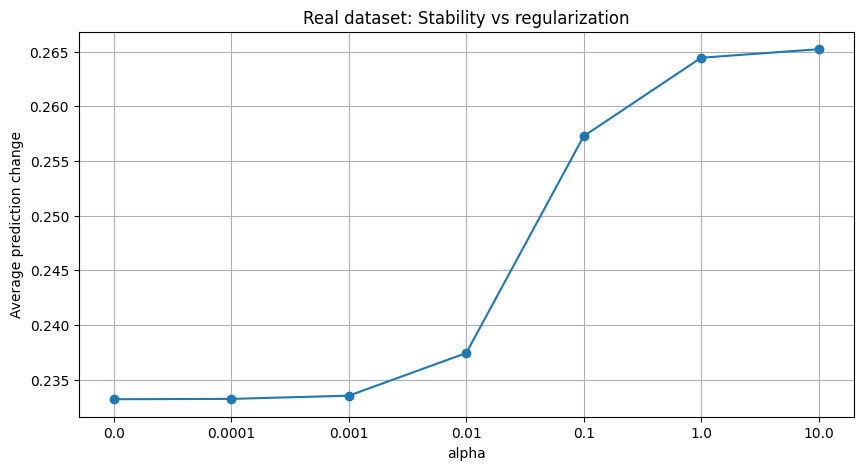

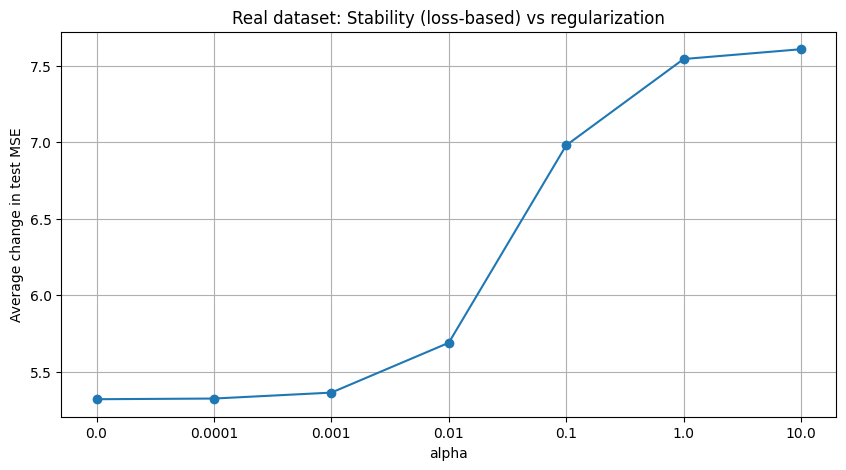

In [605]:
real_results_df = run_stability_experiment(
    X_real_train, y_real_train,
    X_real_val, y_real_val,
    X_real_test, y_real_test,
    alphas=[0, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
    epochs=3000,
    lrs=[1e-4, 1e-3, 1e-2],
    max_removed_points=40
)

print(real_results_df)
plot_stability_results(real_results_df, title_prefix="Real dataset")

## Synthetic dataset

alpha: 0 | lr: 0.0001 | train_mse: 3.3261117347542606 | test_mse: 11.525550901885373 | stability_pred: 0.10608964346084172 | stability_loss: 0.15576779898801407
alpha: 0.0001 | lr: 0.0001 | train_mse: 3.3262144395222677 | test_mse: 11.525670945520973 | stability_pred: 0.10608723516324016 | stability_loss: 0.15576508437149447
alpha: 0.001 | lr: 0.0001 | train_mse: 3.3271391029696877 | test_mse: 11.526751336305287 | stability_pred: 0.10606556428800945 | stability_loss: 0.15574065628693468
alpha: 0.01 | lr: 0.0001 | train_mse: 3.3364173428885167 | test_mse: 11.537555018523335 | stability_pred: 0.10584923152731743 | stability_loss: 0.15549671801737208
alpha: 0.1 | lr: 0.0001 | train_mse: 3.4322356875967044 | test_mse: 11.645536342419348 | stability_pred: 0.10372495495290412 | stability_loss: 0.15309122295693886
alpha: 1 | lr: 0.01 | train_mse: 3.550671989571789 | test_mse: 11.920369488773998 | stability_pred: 0.12055058774886031 | stability_loss: 0.172188267724431
alpha: 10 | lr: 0.01 | tr

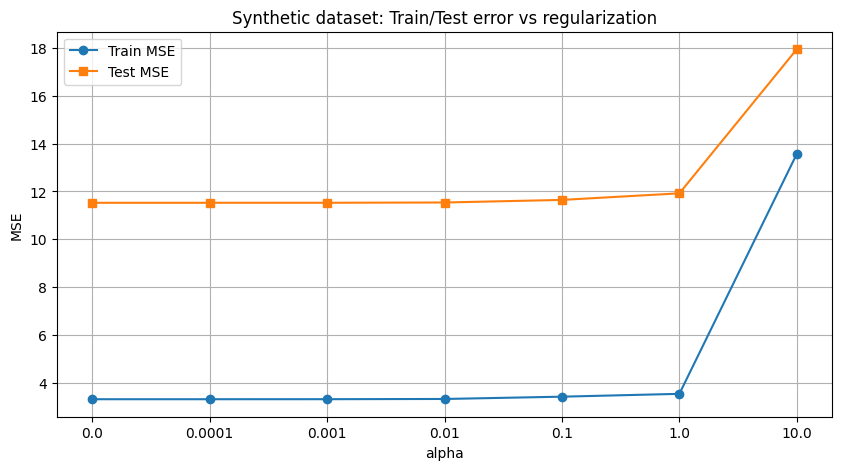

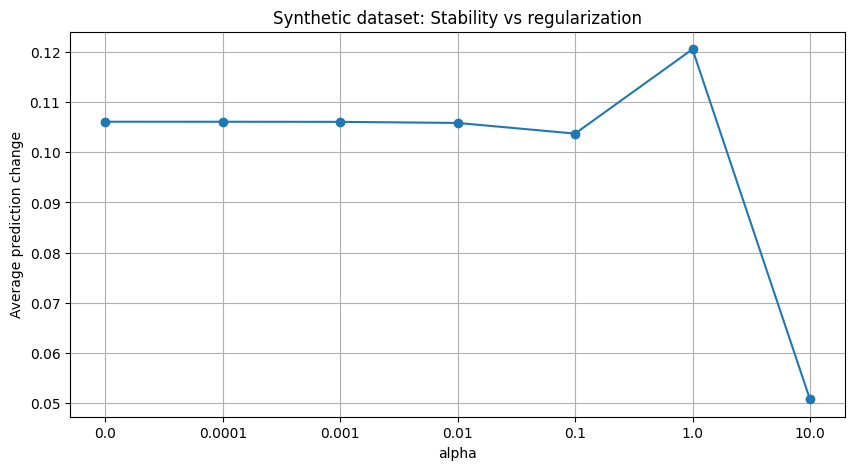

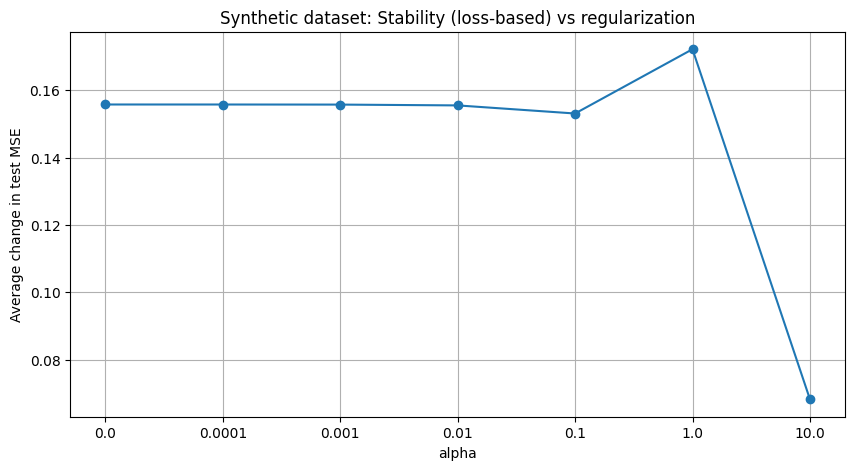

In [606]:
synthetic_results_df = run_stability_experiment(
    X_synt_train, y_synt_train,
    X_synt_val, y_synt_val,
    X_synt_test, y_synt_test,
    alphas=[0, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
    epochs=3000,
    lrs=[1e-4, 1e-3, 1e-2],
    max_removed_points=None
)

print(synthetic_results_df)
plot_stability_results(synthetic_results_df, title_prefix="Synthetic dataset")